# Slavery in Late-19th-Century Siam (1850–1905): A Data-Science Reconstruction

This notebook analyzes slavery in Siam as a system of labor extraction, demographic classification, and state formation, with a specific focus on the exploitation of **Lao / Isan populations**.

## Research question

**What did slavery in Siam look like at scale—economically, demographically, and structurally—and how did it function to benefit Bangkok-centered elites?**

## Notebook roadmap

1. Load the manually coded historical dataset
2. Reconstruct scale and demographics
3. Estimate Lao captive populations and dependency burdens
4. Analyze debt, prices, and the pace of abolition
5. Examine 1904 census coverage, ethnic classification, and omitted Lao regions
6. Recover Bangkok Lao captive-labor communities and their economic roles
7. Relate abolition to state-building and imperial diplomacy

> The core raw dataset is `historical_observations.csv`. Each row is a structured historical observation manually coded from primary and high-value secondary sources.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import networkx as nx

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'

obs = pd.read_csv(RAW / 'historical_observations.csv')
sources = pd.read_csv(RAW / 'source_registry.csv')

pd.set_option('display.max_columns', 50)
obs.head()

,obs_id,source_id,observation_year,period,location,region,population_group,ethnicity_admin,ethnicity_inferred,gender,age_group,status,sector,beneficiary,theme,variable,value_numeric,value_text,unit,lower_bound,upper_bound,estimate_type,inferred,page_or_section,source_quote,coding_note
0,OBS0001,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Malay,Malay,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,5000.0,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...
1,OBS0002,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Cochin Chinese,Cochin Chinese,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,10000.0,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...
2,OBS0003,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Peguan,Peguan,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,10000.0,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...
3,OBS0004,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Lao,Lao,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,20000.0,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...
4,OBS0005,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Burmese,Burmese,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,1000.0,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...


## 1. The manually coded source base

The source registry lets us separate **primary** from **secondary** material and keep URLs attached to every source.


In [2]:
sources[['source_id','short_citation','year','primary_source','url']]

,source_id,short_citation,year,primary_source,url
0,S01,"Bowring 1857, vol. 1",1857,True,https://archive.org/download/kingdompeoplesi1b...
1,S02,British Consular Report 1880,1881,True,https://seadelt.net/Asset/Source/Document_ID-2...
2,S03,The Kingdom of Siam 1904,1904,True,https://ia601301.us.archive.org/22/items/kingd...
3,S04,"FRUS 1905, d930",1905,True,https://history.state.gov/historicaldocuments/...
4,S05,"FRUS 1905, d927",1905,True,https://history.state.gov/historicaldocuments/...
5,S06,Great Britain-France Declaration 1904,1905,True,https://treaties.fcdo.gov.uk/data/Library2/pdf...
6,S07,Grabowsky 1996,1996,False,https://thesiamsociety.org/wp-content/uploads/...
7,S08,Van Roy 2009,2009,False,https://so06.tci-thaijo.org/index.php/pub_jss/...
8,S09,Cruikshank 1975,1975,False,https://thesiamsociety.org/wp-content/uploads/...
9,S10,"Le May 1920, Coinage of Siam",1920,False,https://thesiamsociety.org/wp-content/uploads/...


## 2. What does the raw observation table look like?

The long-form structure is deliberate: budgets, legal rules, prices, demographic counts, and coded qualitative facts can coexist without being forced into one misleading panel format.


In [3]:
obs.sample(10, random_state=7)

,obs_id,source_id,observation_year,period,location,region,population_group,ethnicity_admin,ethnicity_inferred,gender,age_group,status,sector,beneficiary,theme,variable,value_numeric,value_text,unit,lower_bound,upper_bound,estimate_type,inferred,page_or_section,source_quote,coding_note
182,OBS0183,S07,1904,1903-1904,Krung Kao,Detailed 1904 census,households,NaN,NaN,NaN,NaN,household stock,housing,households,welfare_proxy,houses_count,183147.00,NaN,houses,NaN,NaN,reported,0,Table 2b,NaN,NaN
212,OBS0213,S07,1904,1903-1904,Phitsanulok,Detailed 1904 census,religious institutions,NaN,NaN,NaN,NaN,monastic population,religion,sangha,welfare_proxy,monks_and_novices_count,5387.00,NaN,persons,NaN,NaN,reported,0,Table 2b,NaN,NaN
94,OBS0095,S03,1904,1903-1904,Siam,Kingdom-wide,official narrative,NaN,Lao,NaN,NaN,state description,official narrative,state,narrative_code,large_numbers_of_lao_recruits_to_police,1.00,NaN,binary,NaN,NaN,reported,0,Descriptive chapters,NaN,large numbers of Laos from Korat and Lopburi j...
84,OBS0085,S03,1904,1903-1904,Siam,Kingdom-wide or Bangkok,state finance / trade,NaN,NaN,NaN,NaN,state or trade metric,state finance / trade,state / merchants,public_finance,police_force_total,3580.00,NaN,persons,NaN,NaN,reported,0,Bangkok police,NaN,NaN
3,OBS0004,S01,1855,mid-1850s,Siam,Kingdom-wide / crown domain,royal war captives (fighting men),Lao,Lao,male,adult,war captive / royal slave,military / state labor,monarchy,demography,count_fighting_men,20000.00,NaN,persons,NaN,NaN,reported,0,"vol. 1, pp. 190-191",These nearly all belong to the Kings.,Bowring notes the figures include fighting men...
121,OBS0122,S07,1904,1903-1904,Twelve detailed monthons,Detailed 1904 census,resident population,Shan,Shan,NaN,NaN,census race total,registration,state,ethnicity,race_total_in_detailed_monthons,944.00,NaN,persons,NaN,NaN,reported,0,Table 1,NaN,NaN
97,OBS0098,S07,1904,1903-1904,Siam,Kingdom-wide,commoners (chai chakan),NaN,NaN,male,able-bodied,taxable commoners,registration,state,demography,able_bodied_commoners_share_of_population,0.25,NaN,share,NaN,NaN,reported,0,Introduction / census explanation,NaN,NaN
238,OBS0239,S09,1890,late nineteenth century,Siam,Central Siam,slaves,NaN,NaN,NaN,NaN,slave labor,cash alternative,state,labor,slave_cash_alternative,1.50,NaN,baht,NaN,NaN,reported,0,corvée comparison,NaN,NaN
139,OBS0140,S07,1904,1903-1904,Nakhon Si Thammarat,Detailed 1904 census,Malay population,Malay,Malay,NaN,NaN,census ethnicity count,registration,state,ethnicity,ethnic_population_by_monthon,240642.00,NaN,persons,NaN,NaN,reported,0,Malay section,NaN,NaN
122,OBS0123,S07,1904,1903-1904,Twelve detailed monthons,Detailed 1904 census,resident population,Burmese,Burmese,NaN,NaN,census race total,registration,state,ethnicity,race_total_in_detailed_monthons,607.00,NaN,persons,NaN,NaN,reported,0,Table 1,NaN,NaN


## 3. Scale of slavery

Mid-century Siam did not leave a modern slave census. To reconstruct scale, the project uses **scenario estimation** built from:
- Bowring's population bounds (4.5–5.0 million)
- Pallegoix's 6 million benchmark, cited by Bowring
- claims that slaves were around one fourth of the population, and Bowring's claim that the share was **more than a third**


In [4]:
slave_scale_scenarios = pd.read_csv(PROCESSED / 'slave_scale_scenarios.csv')
slave_scale_scenarios

,scenario,population_estimate,slave_share_assumed,estimated_slave_population,basis
0,Conservative lower bound,4500000,0.25,1125000.0,Bowring lower population bound x quarter-slave...
1,Pallegoix quarter benchmark,6000000,0.25,1500000.0,Pallegoix population cited by Bowring x quarte...
2,Bowring high-slavery central,5000000,0.35,1750000.0,Bowring upper population bound x 'more than a ...
3,Upper plausible bound,6000000,0.35,2100000.0,Pallegoix population x Bowring 'more than a th...


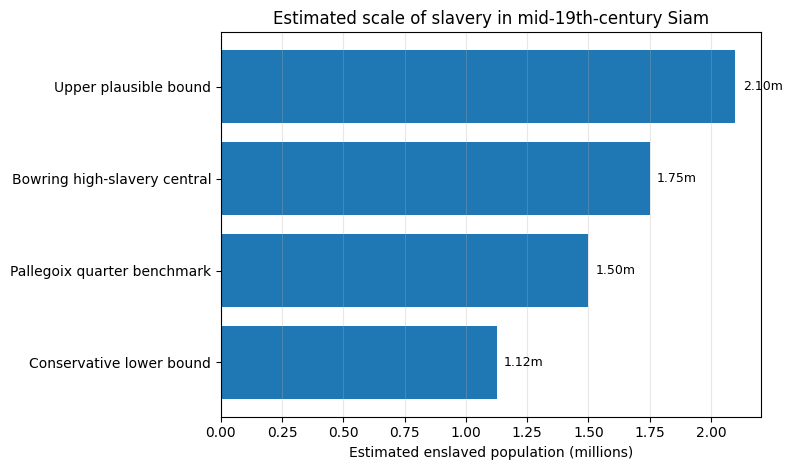

In [5]:
plt.figure(figsize=(8,4.8))
plot_df = slave_scale_scenarios.sort_values('estimated_slave_population')
plt.barh(plot_df['scenario'], plot_df['estimated_slave_population']/1e6)
plt.xlabel('Estimated enslaved population (millions)')
plt.title('Estimated scale of slavery in mid-19th-century Siam')
for i, v in enumerate(plot_df['estimated_slave_population']/1e6):
    plt.text(v + 0.03, i, f'{v:.2f}m', va='center', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Even conservative assumptions imply an enslaved population above one million. Under stronger interpretations of Bowring's “more than a third” language, the estimate moves above two million.


## 4. Lao royal captives and dependent-inclusive reconstruction

Bowring's list of royal war captives reports **20,000 Lao fighting men**, larger than any other listed group. Because Bowring says the figures are for fighting men, not full households, the project uses a dependent multiplier informed by Grabowsky's statement that tax-paying able-bodied men were roughly one fourth of the population.


In [6]:
royal = pd.read_csv(PROCESSED / 'royal_captive_population_scenarios.csv')
central = royal[royal['dependent_multiplier']==4].copy()
central

,ethnicity,fighting_men,dependent_multiplier,estimated_total_population,assumption_basis
1,Malay,5000,4,20000,Adult male fighting-men count scaled by househ...
4,Cochin Chinese,10000,4,40000,Adult male fighting-men count scaled by househ...
7,Peguan,10000,4,40000,Adult male fighting-men count scaled by househ...
10,Lao,20000,4,80000,Adult male fighting-men count scaled by househ...
13,Burmese,1000,4,4000,Adult male fighting-men count scaled by househ...


In [7]:
lao_share = central.loc[central['ethnicity']=='Lao','fighting_men'].iloc[0] / central['fighting_men'].sum()
lao_share

np.float64(0.43478260869565216)

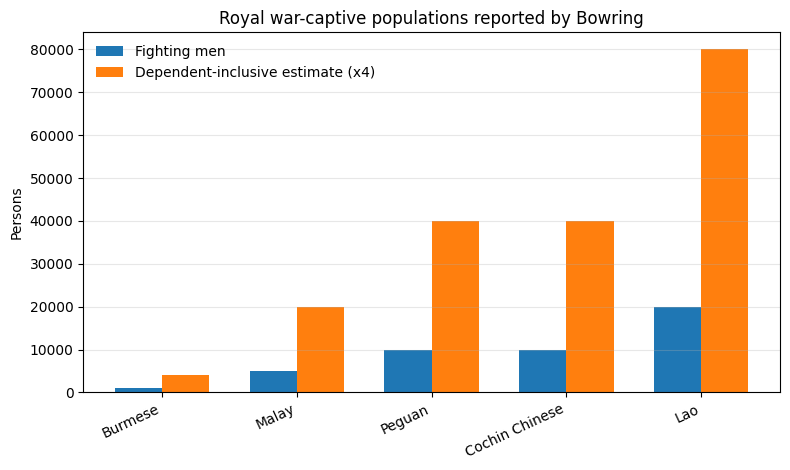

In [8]:
plt.figure(figsize=(8,4.8))
plot_df = central.sort_values('fighting_men')
x = np.arange(len(plot_df))
width = 0.35
plt.bar(x - width/2, plot_df['fighting_men'], width, label='Fighting men')
plt.bar(x + width/2, plot_df['estimated_total_population'], width, label='Dependent-inclusive estimate (x4)')
plt.xticks(x, plot_df['ethnicity'], rotation=25, ha='right')
plt.ylabel('Persons')
plt.title('Royal war-captive populations reported by Bowring')
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation:

- Lao make up roughly **43.5%** of the listed royal captive fighting men.
- A multiplier of 4 yields a central estimate of about **80,000 Lao captives plus dependents** tied to the crown.
- This is an inference, not a direct census, but it provides a transparent order-of-magnitude estimate.


## 5. Gender, childhood, and debt

Bowring's slavery chapters allow a small but informative reconstruction of **gendered pricing** and **intergenerational bondage**.


In [9]:
prices = obs[(obs['source_id']=='S01') & (obs['theme'].isin(['price','debt']))][['variable','gender','age_group','value_numeric','unit','source_quote','coding_note']]
prices.head(12)

,variable,gender,age_group,value_numeric,unit,source_quote,coding_note
12,price_male_min,male,adult,80.0,ticals,NaN,NaN
13,price_male_max,male,adult,120.0,ticals,NaN,NaN
14,price_female_min,female,adult,60.0,ticals,NaN,NaN
15,price_female_max,female,adult,100.0,ticals,NaN,NaN
17,example_sale_price,male,child,100.0,ticals,husband and wife sell son Pau for 100 ticals,NaN
18,illustrative_inflated_debt_note,NaN,NaN,400.0,ticals,NaN,"Bowring notes that breakage, borrowing, and ad..."
19,fixed_redemption_price_at_manhood,NaN,adult,48.0,ticals,NaN,NaN
21,rice_dear_standard_price_woman,female,adult,48.0,ticals,NaN,NaN
22,rice_dear_standard_price_man,male,adult,56.0,ticals,NaN,NaN


The 1905 abolition law did not erase debts instantly. It credited **4 ticals per month** against slave debt, so the speed of freedom depended on the size of the inherited or accumulated obligation.


In [10]:
debt = pd.read_csv(PROCESSED / 'debt_burden_scenarios.csv')
debt

,case,debt_ticals,monthly_credit_1905,months_to_freedom_under_1905_law
0,Female redeemable slave (low price),60,4,15.0
1,Female redeemable slave (high price),100,4,25.0
2,Male redeemable slave (low price),80,4,20.0
3,Male redeemable slave (high price),120,4,30.0
4,Birth slave fixed price at manhood,48,4,12.0
5,Illustrative child sale,100,4,25.0
6,Inflated debt paper example,400,4,100.0


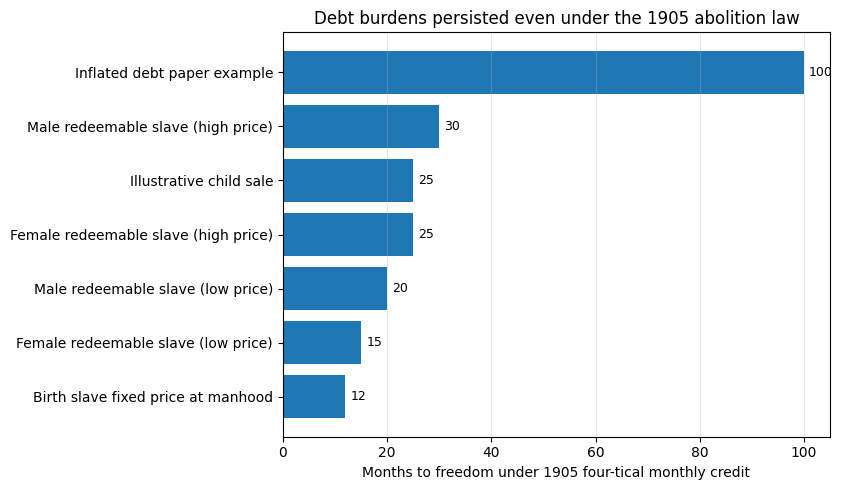

In [11]:
plt.figure(figsize=(8.5,5))
plot_df = debt.sort_values('months_to_freedom_under_1905_law')
plt.barh(plot_df['case'], plot_df['months_to_freedom_under_1905_law'])
plt.xlabel('Months to freedom under 1905 four-tical monthly credit')
plt.title('Debt burdens persisted even under the 1905 abolition law')
for i, v in enumerate(plot_df['months_to_freedom_under_1905_law']):
    plt.text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

This is important for interpretation: abolition was not simply a switch from “slave” to “free”. It often involved **time-dependent debt extinguishing**, which could still lock people into labor for years.


## 6. Census coverage, ethnicity, and the Lao / Isan problem

The 1904 census is extremely valuable, but it is also politically structured:
- only 12 monthons were enumerated in detail
- Udon, Isan, and Phayap were omitted from the detailed count
- Lao were often administratively folded into the category “Thai”


In [12]:
coverage = pd.read_csv(PROCESSED / 'census_coverage_1904.csv')
coverage

,component,population,share_of_national_total,detailed_enumeration,lao_heartland_or_related
0,Detailed-count monthons,3308032.0,0.494707,1,0
1,Udon,576947.0,0.086281,0,1
2,Isan,915750.0,0.136948,0,1
3,Phayap,485563.0,0.072615,0,1
4,Krung Thep,493677.0,0.073828,0,0
5,Burapha,208868.0,0.031236,0,0
6,Saiburi,219000.0,0.032751,0,0
7,Kelantan,300000.0,0.044864,0,0
8,Tringganu,114895.0,0.017182,0,0


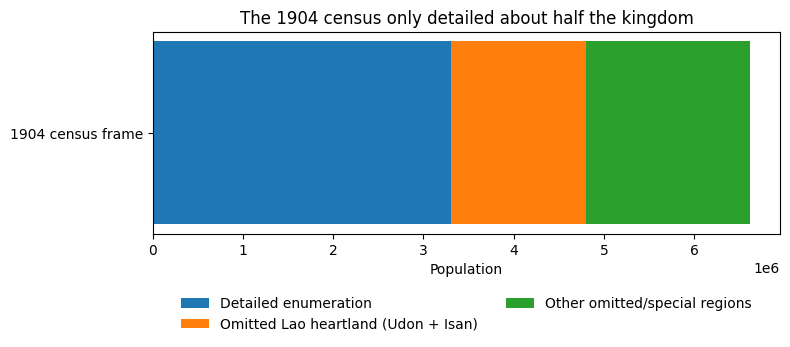

In [13]:
detailed = coverage.loc[coverage['component']=='Detailed-count monthons','population'].iloc[0]
lao_heart = coverage.loc[coverage['component'].isin(['Udon','Isan']),'population'].sum()
other_omitted = coverage.loc[~coverage['component'].isin(['Detailed-count monthons','Udon','Isan']),'population'].sum()
total = detailed + lao_heart + other_omitted

plt.figure(figsize=(8,3.8))
plt.barh(['1904 census frame'], [detailed], label='Detailed enumeration')
plt.barh(['1904 census frame'], [lao_heart], left=[detailed], label='Omitted Lao heartland (Udon + Isan)')
plt.barh(['1904 census frame'], [other_omitted], left=[detailed+lao_heart], label='Other omitted/special regions')
plt.xlabel('Population')
plt.title('The 1904 census only detailed about half the kingdom')
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5,-0.25), ncol=2)
plt.tight_layout()
plt.show()

The omission is not trivial. Udon + Isan alone account for more than one fifth of the kingdom's estimated population. That means any ethnicity or labor interpretation built only from the detailed-census monthons will systematically understate Lao / Isan weight.


### Monthon populations in the detailed census


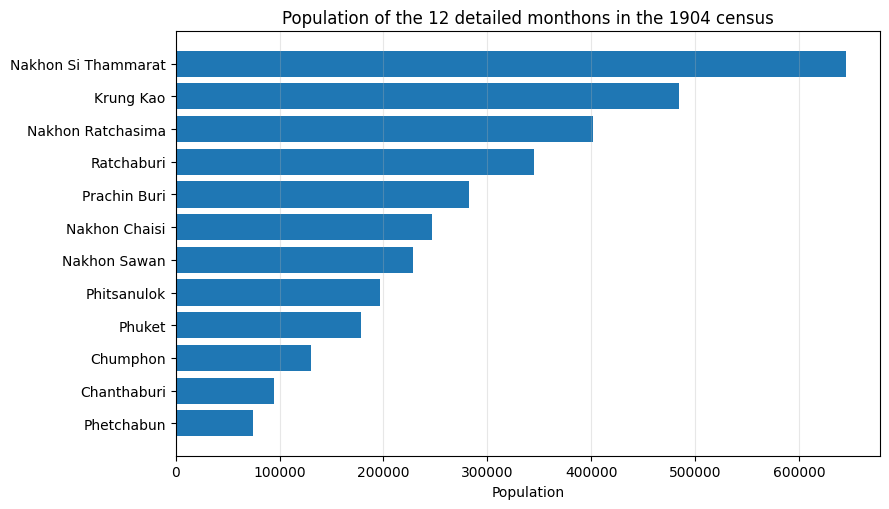

In [14]:
monthon_population_1904 = pd.read_csv(PROCESSED / 'monthon_population_1904.csv')
plt.figure(figsize=(9,5.2))
plot_df = monthon_population_1904.sort_values('population', ascending=True)
plt.barh(plot_df['monthon'], plot_df['population'])
plt.xlabel('Population')
plt.title('Population of the 12 detailed monthons in the 1904 census')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Race totals in the 12 detailed monthons


In [15]:
race_totals = pd.read_csv(PROCESSED / 'race_totals_1904_detailed_monthons.csv')
race_totals

,ethnicity,population,share_of_detailed_population
0,Thai,2677987.0,0.809564
1,Malay,289423.0,0.087494
2,Chinese,195498.0,0.059100
3,Khmer,78704.0,0.023792
4,Mon,29156.0,0.008814
5,Karen,19257.0,0.005821
6,Others,8936.0,0.002701
7,Vietnamese,4757.0,0.001438
8,Cham,1601.0,0.000484
9,Shan,944.0,0.000285


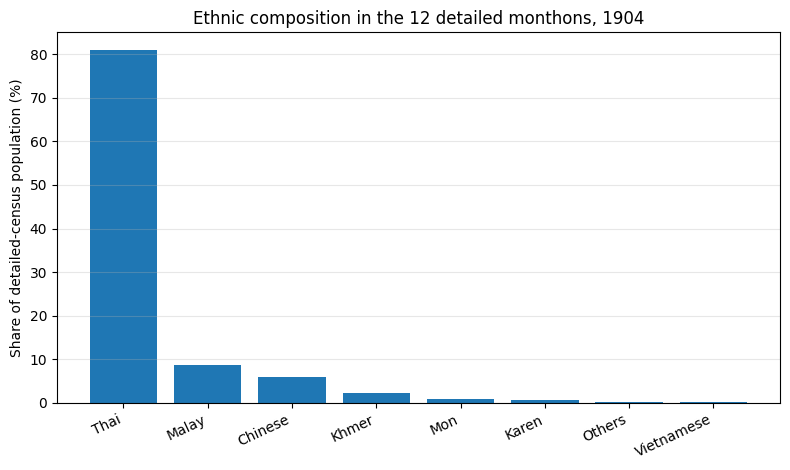

In [16]:
plot_df = race_totals.copy()
plot_df['share_pct'] = plot_df['share_of_detailed_population'] * 100
plot_df = plot_df.sort_values('share_pct', ascending=False).head(8)

plt.figure(figsize=(8,4.8))
plt.bar(plot_df['ethnicity'], plot_df['share_pct'])
plt.ylabel('Share of detailed-census population (%)')
plt.title('Ethnic composition in the 12 detailed monthons, 1904')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The race totals are informative, but not neutral. The same census apparatus that counted households and draught animals also helped **erase Lao as a named population** by absorbing them administratively into “Thai”.


## 7. Bangkok Lao captive-labor communities

Van Roy's community reconstructions make it possible to treat Lao captivity not just as a legal status but as an **urban labor allocation system**.


In [17]:
communities = pd.read_csv(PROCESSED / 'lao_captive_communities.csv')
communities

,community,origin_polity,captive_group,location_type,primary_labor,secondary_labor,beneficiary_primary,gendered_pathway,status_transition,source_id
0,Bang Yi-khan,Vientiane,royal captives and retainers,Bangkok community,elite-household incorporation,government service,Thai elite / royal household,Daughters absorbed as wives/consorts; sons int...,captive to incorporated elite-linked households,S08
1,Bang Khun Phrom,Lao Phuan,war captives,Bangkok community,fresh-water naval craft construction,boat basin digging,Front Palace / royal navy,Not specified,captive labor under palace patronage,S08
2,Thewet,Champasak,ruler's family and artisans,Bangkok community,goldsmithing,blacksmithing,court / noble households,Not specified,captive artisan service,S08
3,Ban Kruai / Yannawa,Bang Sai Kai / Lao resettlement,able-bodied Lao captives,river-port / industrial,sawmills and shipyards,stevedoring and warehousing,Western firms / port economy,Not specified,war captive labor to wage labor,S08
4,Ban Lao Phuan,Lao Phuan,laborers,palace service settlement,palace landscaping and sanitation,elephant service,Grand Palace / Royal Household,Women’s quarters maintenance under palace depa...,state slave labor to freemen later evicted,S08
5,Ban Kraba,evicted Lao community,former captive descendants,peri-urban resettlement,wickerware,petty commerce,urban consumer economy,Household-based artisanal and petty trade labor,freed but economically precarious,S08
6,Ban Ti Thong / Ban Chang Thong,Lao goldsmith captives,artisans,artisan quarter,gold beating / gold leaf / filigree,"medallions, insignia, munitions",noble households / military and police suppliers,Not specified,captive artisan labor to specialized urban cra...,S08


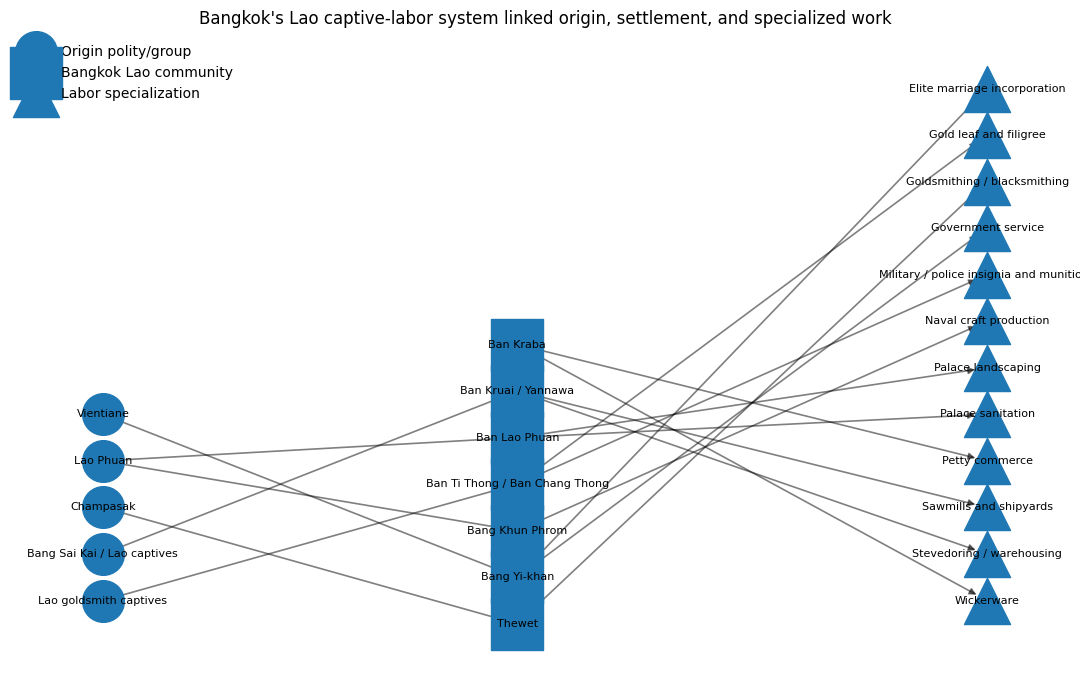

In [18]:
edges = pd.read_csv(PROCESSED / 'lao_labor_network_edges.csv')
G = nx.DiGraph()
for _, r in edges.iterrows():
    G.add_edge(r['source_node'], r['target_node'], edge_type=r['edge_type'])

origin_nodes = [n for n in G.nodes if n in ['Vientiane','Lao Phuan','Champasak','Bang Sai Kai / Lao captives','Lao goldsmith captives']]
community_nodes = [n for n in G.nodes if n in communities['community'].tolist()]
labor_nodes = [n for n in G.nodes if n not in origin_nodes + community_nodes]

pos = {}
for i, n in enumerate(origin_nodes):
    pos[n] = (0, len(origin_nodes)-i)
for i, n in enumerate(sorted(community_nodes)):
    pos[n] = (1.5, len(community_nodes)-i-0.5)
for i, n in enumerate(sorted(labor_nodes)):
    pos[n] = (3.2, len(labor_nodes)-i)

plt.figure(figsize=(11,7))
nx.draw_networkx_edges(G, pos, arrows=True, alpha=0.5, width=1.2, arrowstyle='-|>')
nx.draw_networkx_nodes(G, pos, nodelist=origin_nodes, node_shape='o', node_size=900, label='Origin polity/group')
nx.draw_networkx_nodes(G, pos, nodelist=community_nodes, node_shape='s', node_size=1400, label='Bangkok Lao community')
nx.draw_networkx_nodes(G, pos, nodelist=labor_nodes, node_shape='^', node_size=1100, label='Labor specialization')
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Bangkok's Lao captive-labor system linked origin, settlement, and specialized work")
plt.legend(frameon=False, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

The network makes a crucial point visible: Lao captives were not peripheral. They were routed into **court labor, palace sanitation, naval craft, port logistics, shipyards, artisanal metalwork, and later urban petty production**.


## 8. State-building, trade growth, and abolition

Abolition did not occur in isolation. It happened during a period of:
- expanded bureaucratic capacity
- rising external trade
- diplomatic pressure from Britain and France
- reclassification of subject populations into administratively legible “citizens”


In [19]:
derived = pd.read_csv(PROCESSED / 'derived_metrics.csv')
derived[['metric','value','unit','interpretation']]

,metric,value,unit,interpretation
0,Estimated enslaved population lower bound,1.125000e+06,persons,Conservative lower-bound scenario for mid-cent...
1,Estimated enslaved population upper bound,2.100000e+06,persons,Upper plausible scenario for mid-century slave...
2,Lao share of listed royal war captives,4.347826e-01,share,Lao were the single largest group among Bowrin...
3,Estimated Lao captive population with dependen...,8.000000e+04,persons,Central multiplier using adult males as one qu...
4,Share of 1904 national population in detailed ...,4.947074e-01,share,Only about half the kingdom was covered by det...
5,Share of national population in Udon and Isan,2.232289e-01,share,Omitted Lao-heartland population share
6,"Share of national population in Udon, Isan, an...",2.958435e-01,share,"If northern Lao-related Phayap is included, om..."
7,Growth factor of Ministry of Local Government ...,5.097087e+01,x,Scale-up of central administrative capacity
8,Bangkok police + sanitation as share of 1903-0...,4.971594e-02,share,Visible Bangkok-centered spending share
9,Export growth 1897 to 1902,5.150321e-01,share,Trade expansion during late reform era


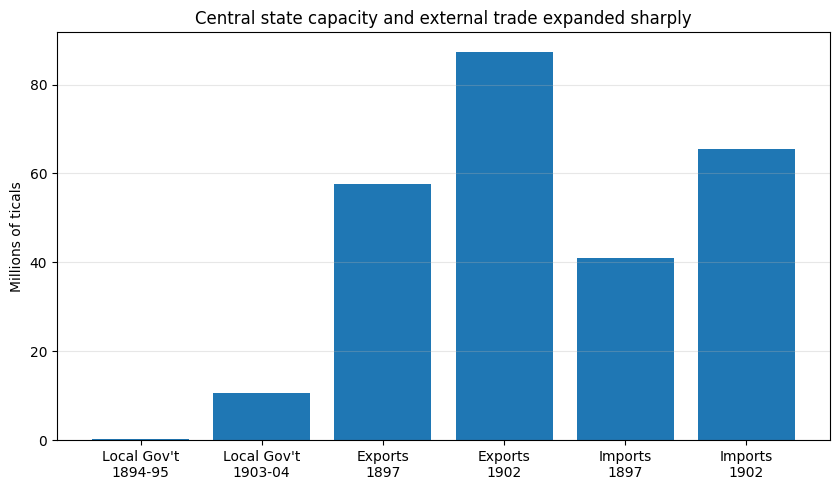

In [20]:
plt.figure(figsize=(8.5,5))
cats = ['Local Gov\'t\n1894-95','Local Gov\'t\n1903-04','Exports\n1897','Exports\n1902','Imports\n1897','Imports\n1902']
vals = [206000,10500000,57689792,87401889,40973403,65420231]
plt.bar(cats, np.array(vals)/1e6)
plt.ylabel('Millions of ticals')
plt.title('Central state capacity and external trade expanded sharply')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
timeline = pd.read_csv(PROCESSED / 'abolition_timeline.csv')
timeline[['year','event','type','domestic_reform_score','external_pressure_score','notes']]

,year,event,type,domestic_reform_score,external_pressure_score,notes
0,1874,Born Slave Price Reduction Act / law of Pee Chau,domestic reform,5,1,Freed those born after 1868 gradually and curt...
1,1893,Franco-Siamese crisis,foreign pressure,1,5,French pressure sharpened attention to Lao cap...
2,1897,Renewed ban on further sales,domestic reform,4,2,Chulalongkorn restated that no further sales s...
3,1899,Corvée commuted to head tax,labor regime reform,4,2,Shifted coercive extraction from labor service...
4,1899,Draft nationality law discussed,citizenship / classification,3,4,Citizenship reform tied to management of capti...
5,1904,Anglo-French declaration concerning Siam,foreign pressure,1,4,Placed Siam in a formalized imperial diplomati...
6,1904,Siam-French convention,foreign pressure,1,4,Territorial and jurisdictional settlement with...
7,1905,Law for the Abolition of Slavery,domestic reform,5,3,"No new slaves, children free, and debt credite..."
8,1913,Nationality Act,citizenship consolidation,4,2,Birth in Siam became a stronger basis for lega...


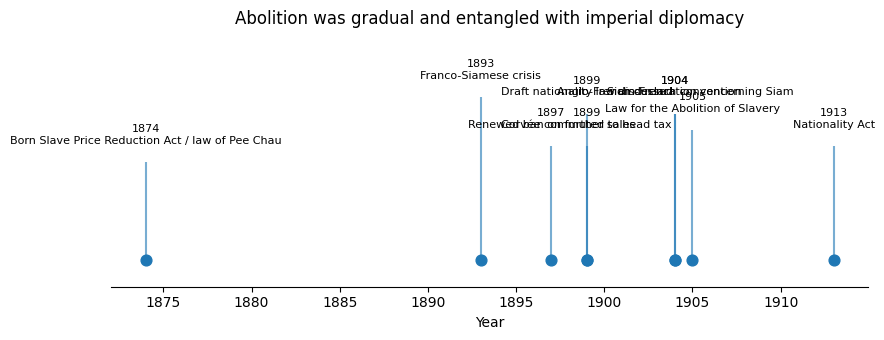

In [22]:
plt.figure(figsize=(9,3.5))
y = np.zeros(len(timeline))
plt.scatter(timeline['year'], y, s=60)
for _, r in timeline.iterrows():
    plt.vlines(r['year'], 0, 0.15 + 0.03*(r['external_pressure_score']), alpha=0.6)
    plt.text(r['year'], 0.18 + 0.03*(r['external_pressure_score']), str(r['year']) + '\n' + r['event'], ha='center', va='bottom', fontsize=8)
plt.ylim(-0.05, 0.42)
plt.yticks([])
plt.xlabel('Year')
plt.title('Abolition was gradual and entangled with imperial diplomacy')
for spine in ['left','right','top']:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Interpretation

### Evidence-based conclusions
- Slavery in Siam was not marginal; it was a large social institution likely involving well over a million people.
- Lao were central to crown-controlled captive labor, especially in the royal and Bangkok urban sphere.
- Debt, corvée alternatives, and tax structures made dependency economically rational for rulers and often coercively rational for subordinates.
- Abolition was gradual and did not simply end coercion; it rechanneled labor into monetized and bureaucratically regulated forms.

### Inferred but transparent conclusions
- The state had incentives to suppress named Lao ethnicity because classification affected sovereignty, labor control, and diplomatic vulnerability.
- Late-nineteenth-century emancipation partly transformed captive labor into labor for the bureaucracy, municipality, western firms, and Chinese commercial networks rather than eliminating extraction.

## 10. Limitations

- The raw sources are elite-authored and geographically uneven.
- The 1904 census is informative but incomplete.
- The project estimates **orders of magnitude** and structural patterns, not exact micro-level totals.

## 11. Reproducibility note

The figures in the report were generated from the same CSVs used here. For a polished written synthesis, see `../report/`.
